# Hyperparameters and Model Validation


## Overfitting

In the last lecture, we saw that a reasonably simple decision tree was able to achieve almost 80\% accuracy in modeling from demographic data whether or not a given passenger survived the Titanic. However, we shouldn't take this result at face value. To see why, let's take a look at an example, in the context of regression (i.e. predicting a quantitative variable). 

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
np.random.seed(1234)
X = np.random.rand(10)
y = np.log(X) + 0.1*np.random.randn(len(X))


# in this block generating data

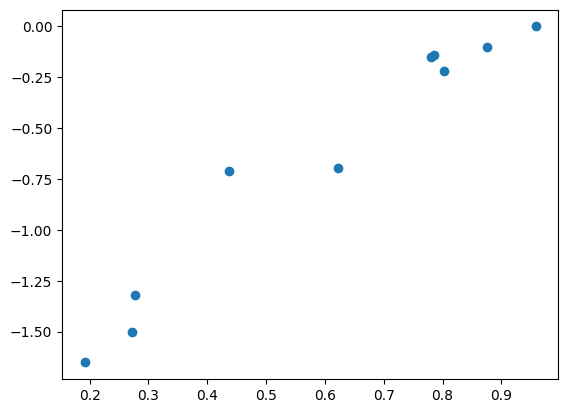

In [3]:
fig, ax = plt.subplots(1,1)
ax.scatter(X,y)

#fig, ax = plt.subplots(1,1)
#ax.scatter or ax.plot

Now we're going to do *polynomial regression*. This is the simplest version of what's often called "curve-fitting." In this case, we'll allow the degree of the polynomial to vary. Degree 1 corresponds to linear regression, while higher degrees allow for more complicated curves. Since this is just an illustrative example, it's not necessary for you to understand how this function works at the moment. 

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

def PolynomialRegression(degree = 2, **kwargs):
    return make_pipeline(PolynomialFeatures(degree),LinearRegression(**kwargs))

The return value of `PolynomialRegression()` is a model, which we can then fit. There is an unfortunate syntactic requirement here -- we need to transform `X`, which is currently a 1d array, into a 2d array in which the second dimension has length 1.   

In [5]:
X.shape


# just checking the shape

(10,)

In [6]:
y.shape     # checking the shape

(10,)

In [7]:
X[:,None].shape

(10, 1)

That's it for model fitting! Let's check quantitatively how we did: 

In [8]:
model1 = PolynomialRegression(1).fit(X[:, None], y)
model2 = PolynomialRegression(10).fit(X[:, None], y)


# now we are runnign the .fit on it

In [9]:
model1.score(X[:, None], y), model2.score(X[:, None], y)    


# now doing the .score to see how the models did!

(0.9525931944971778, 1.0)

The way that the score is computed depends on the model, but for this class of models the highest possible value of the score is 1. So, `model2` achieves essentially a perfect score, whereas `model1` achieves a noticeably lower score. 

Let's visualize to see how `model2` achieved such an impressive score. 

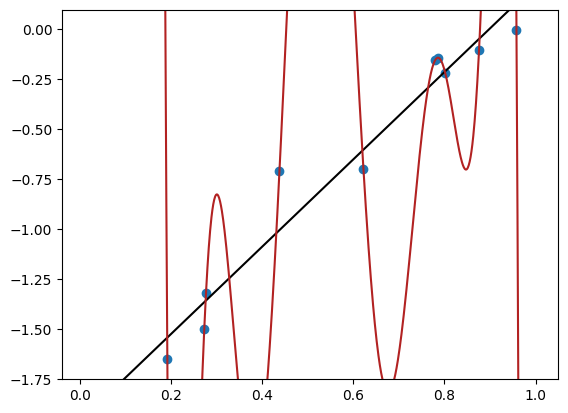

In [10]:
# we see from prev cell that model 2 gives us a score of 1.0!
xfit = np.linspace(0.01, 1, 1000)[:,None]
ax.plot(xfit, model1.predict(xfit), color='black')
ax.plot(xfit, model2.predict(xfit), color='firebrick')
ax.set(ylim=(y.min() - 0.1, y.max() + 0.1))
fig


# now we are just graphing our results to see them

The black line is the simple, degree 1 model, while the wavy red line is more complicated, degree 10 model. Note something interesting: the degree 10 model fits each of the data points exactly! Perfect prediction, no error! Machine learning is easy. 

<br> 

Of course, the situation isn't really that simple. Remember that what we usually want to do in machine learning is not just fit a curve to data, but actually **predict unseen data**. To see the problem with `model2`, let's generate some new, unseen data and see how the two models do on the prediction task.   

In [11]:
X_new = np.random.rand(10)
y_new = np.log(X_new) + 0.1*np.random.randn(len(X_new))

# generating new data

In [13]:
model1.score(X_new[:, None], y_new), model2.score(X_new[:,None], y_new)



# now we are scoring with oru prev models, we see tha the second model scored HORRID!

(0.8096821682305582, -70179.96852076614)

Woops! This time, `model1`'s score is similar to what it achieved previously, but `model2`'s score is actually negative-very negative. The useless model that just guesses `0` for each prediction would have yielded a score of `0`, so `model2` is literally worse than useless. We can see this when we visualize: `model2` perfectly fits the original points, but is often badly off on the new ones. In contrast, `model1` is pretty close. 

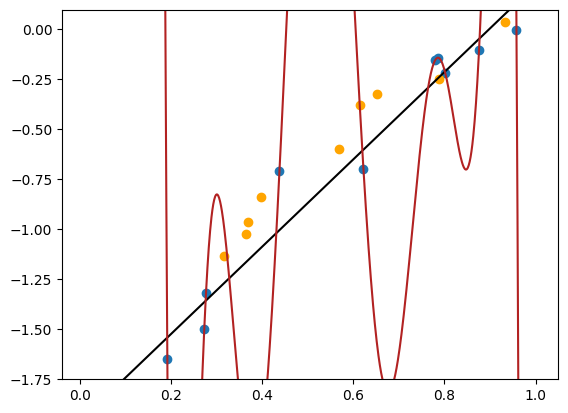

In [14]:
# the straight line is model 1 that isnt perfect but is ok 
ax.scatter(X_new, y_new, color='orange')
fig
# can see that model 2 sucks for the new data!

**Overfitting** refers to the phenomenon in which a machine learning model fits the *random noise* in the data, rather than the *true signal*. A characteristic sign of overfitting is that the model performs much less well on unseen data than on the data to which it was fit. In our case, we would say that `model2` is badly overfit -- it focused so much on the random wiggles in the data that it completely missed the overall upward trend. As a result, it cannot be used for prediction. In contrast, `model1` did ok -- it missed the fact that the true signal in the data is curved, but it can still be used to generate fairly reasonable predictions. 

Another aspect of overfitting is *model flexibility*. The less flexible `model1` didn't have enough flexibility to fit the curved pattern of the data, but it also didn't have enough flexibility to get distracted by the random noise. In contrast, the more flexible `model2` had so much flexibility that it was able to perfectly fit the noise in the data. This interpretation suggests that we should seek models with intermediate degrees of flexibility. Next, we'll discuss how to use model validation techniques to do this, and thereby diagnose and avoid overfitting. 

# **need to avoid overfitting!!!**

## Overfitting in practice

In this section, we'll observe overfitting in a more practical context, using the Titanic data set again. We'll then begin to study *validation* techniques for finding models with "just the right amount" of flexibility. 

In [15]:
import pandas as pd 
titanic = pd.read_csv('titanic.csv')
titanic

# import pandas as pd
# titanic = pd.reas_csv('titanic.csv')

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


# **we can test for overfitting by testing our model against NEW data!**

Recall that we diagnosed overfitting by testing our model against some new data. In this case, we don't have any more data. So, what we can do instead is *hold out* some data that we won't let our model see at first. This holdout data is called the *validation* or *testing* data, depending on the use to which we put it. In contrast, the data that we allow our model to see is called the *training* data. `sklearn` provides a convenient function for partitioning our data into training and holdout sets called `train_test_split`. The default and generally most useful behavior is to randomly select rows of the data frame to be in each set. 

In [16]:
# wanting to split between TRAINING data and TESTING data !! a wonderful concept

from sklearn.model_selection import train_test_split
np.random.seed(1234)
train, test = train_test_split(titanic, test_size = 0.3)
train.shape, test.shape

# train has 620 rows 8 cols
# test has 267 rows same 8 cols



# now introduced to the train_test_split model
# so do
# train, test = train_test_split(titanic, test_siz = 0.3)
# now checking the shape if it so train.shape and test.shape

((620, 8), (267, 8))

Now we have two data frames. As you may recall from a previous lecture, we need to do some data cleaning, and split them into predictor variables `X` and target variables `y`. 

In [31]:
# before doing anything need to do same preprocessing steps that we saw in lecture 18 .. :) 
from sklearn import preprocessing
def prep_titanic_data(data_df):
    df = data_df.copy()
    le = preprocessing.LabelEncoder()
    df['Sex'] = le.fit_transform(df['Sex'])             # we also saw this

    df = df.drop(['Name'],axis=1)   

    X = df.drop(['Survived'], axis=1)
    y = df['Survived']
    return X,y


# same as before but now making a func to do it


# we saw this in the previous lecture 
# from our dataset we want to split it into X and y
# ie for the X we do X = df.drop(['Survived'], axis=1)   so we are dropping the Survived column 

In [32]:
X_train, y_train = prep_titanic_data(train)
X_test, y_test = prep_titanic_data(test)

Now we're able to train our model on the train data, and then evaluate its performance on the val data. This will help us to diagnose and avoid overfitting.

Let's try using the decision tree classifier again. As you may remember, the DecisionTreeClassifier() class takes an argument max_depth that governs how many layers of decisions the tree is allowed to make. Larger max_depth values correspond to more complicated trees. In this way, max_depth is a model complexity parameter, similar to the degree when we did polynomial regression.

For example, with a small max_depth, the model scores on the training and validation data are relatively close.

In [33]:
# now trying a decision tree classifier

from sklearn import tree
T = tree.DecisionTreeClassifier(max_depth=3)
T.fit(X_train, y_train)
T.score(X_train,y_train)


# we saw this the previous lecture
# from sklearn import tree
# T = tree.DecisionTreeClassifier(max_depth=3)
# T.fit(X_train, y_train)
# T.score(X_train,Y_train)

0.8290322580645161

In [34]:
T.score(X_test,y_test)      # not bad

# now score the test dataset

0.8164794007490637

On the other hand, if we use a much higher `max_depth`, we can achieve a substantially better score on the training data, but our performance on the validation data has not improved by much, and might even suffer. 

In [35]:
T = tree.DecisionTreeClassifier(max_depth=20)
T.fit(X_train,y_train)
T.score(X_train,y_train)

0.9903225806451613

In [36]:
T.score(X_test,y_test)

0.7602996254681648

That looks like overfitting! The model achieves a near-perfect score on the training data, but a much lower one on the test data. 

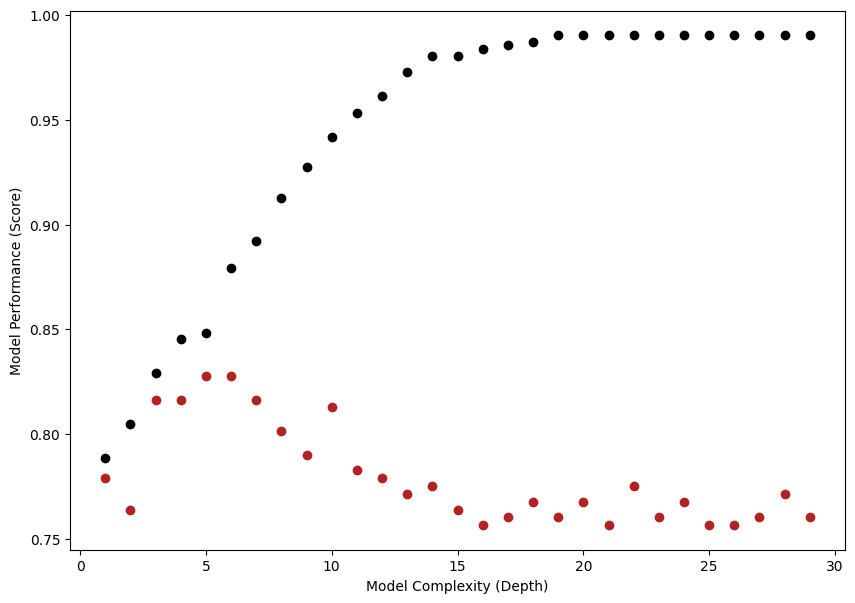

In [37]:
# I guess now visualizing it 
fig, ax = plt.subplots(1,1,figsize=(10,7)) # creating the plot


for d in range(1,30):
    T = tree.DecisionTreeClassifier(max_depth=d)
    T.fit(X_train, y_train)
    ax.scatter(d, T.score(X_train, y_train), color='black')
    ax.scatter(d, T.score(X_test, y_test), color='firebrick')
    ax.set(xlabel='Model Complexity (Depth)',ylabel='Model Performance (Score)')


Observe that the training score (black) always increases, while the test score (red) tops out around 83\% and then even begins to trail off slightly. It looks like the optimal depth might be around 5-7 or so, but there's some random noise that can prevent us from being able to determine exactly what the optimal depth is. 

Increasing performance on the training set combined with decreasing performance on the test set is the trademark of overfitting. 

This noise reflects the fact that we took a single, random subset of the data for testing. In a more systematic experiment, we would draw many different subsets of the data for each value of depth and average over them. This is what *cross-validation* does.

## Cross-Validation and the Test Set

We just saw how keeping some data hidden from our model could help us to get a clearer understanding of whether or not the model was overfitting. Now we'll introduce a common automated framework for handling this task, called **cross-validation**. We'll also incorporate a designated **test set**, which we won't touch until the very end of our analysis to get an overall view of the performance of our model. 

### K-fold Cross-Validation

The idea of k-fold cross validation is to take a small piece of our training data, say 10%, and use that as a mini test set. We train the model on the remaining 90%, and then evaluate on the 10%. We then take a *different* 10%, train on the remaining 90%, and so on. We do this many times, and finally average the results to get an overall average picture of how the model might be expected to perform on the real test set. Cross-validation is a highly efficient tool for estimating the optimal complexity of a model. 

<figure class="image" style="width:100%">
  <img src="https://scikit-learn.org/stable/_images/grid_search_cross_validation.png" alt="Illustration of k-fold cross validation. The training data is sequentially partitioned into 'folds', each of which is used as mini-testing data exactly once. The image shows five-fold validation, with four boxes of training data and one box of testing data. The diagram then indicates a final evaluation against additional testing data not used in cross-validation." width="600px">
    <br>
    <caption><i>K-fold cross-validation. Source: scikit-learn docs.</i></caption>
</figure>

The good folks at `scikit-learn` have implemented a function called `cross_val_score` which automates this entire process. It repeatedly selects holdout data; trains the model; and scores the model against the holdout data. While exceptions apply, you can often use `cross_val_score` as a plug-and-play replacement for `model.fit()` and `model.score()` during your model selection phase. 

In [38]:
from sklearn.model_selection import cross_val_score
from sklearn import tree

T=tree.DecisionTreeClassifier(max_depth=3)      # initializing decision tree classifier model

# now doing cross validation
cv_scores = cross_val_score(T, X_train,y_train,cv=10)
cv_scores


# using cross validation on the training dataset

array([0.67741935, 0.79032258, 0.74193548, 0.83870968, 0.83870968,
       0.79032258, 0.80645161, 0.80645161, 0.83870968, 0.82258065])

In [39]:
cv_scores.mean()

np.float64(0.7951612903225806)

[Text(0.5, 1.0, 'Best Depth: 6'),
 Text(0.5, 0, 'Depth'),
 Text(0, 0.5, 'CV Score')]

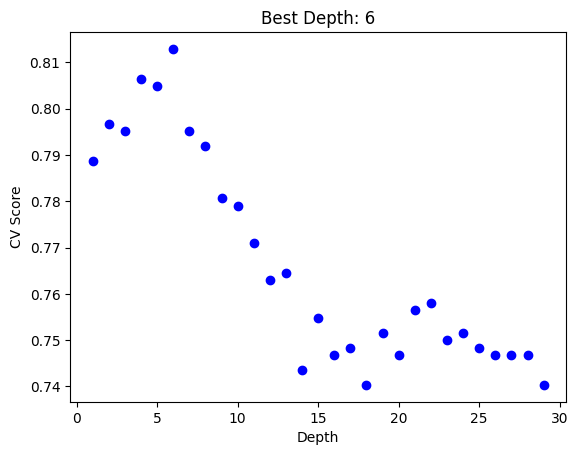

In [40]:
fig, ax = plt.subplots(1,1)
best_score = 0
for d in range(1, 30):
    T = tree.DecisionTreeClassifier(max_depth=d)
    cv_score = cross_val_score(T, X_train, y_train,cv=10).mean()
    ax.scatter(d, cv_score, color='blue')
    if cv_score > best_score:
        best_depth = d
        best_score = cv_score
        
ax.set(title='Best Depth: ' + str(best_depth),
xlabel='Depth',
ylabel='CV Score')


# **okay I can see the vision man**

Now that we have a reasonable estimate of the optimal depth, we can try evaluating against the unseen testing data. 

In [41]:
T = tree.DecisionTreeClassifier(max_depth=best_depth)
T.fit(X_train, y_train)
T.score(X_test, y_test)

0.8277153558052435

Great! We even got slightly higher accuracy on the test set than we did in validation, although this is rare.

# Machine Learning Workflow: The Big Picture

We now have all of the elements that we need to execute the core machine learning workflow. At a high-level, here's what should go into a machine task:

1. Separate out the test set from your data. 
2. Clean and prepare your data if needed. It is best practice to clean your training and test data separately. It's convenient to write a function for this. 
3. Identify a set of candidate models (e.g. decision trees with depth up to 30, logistic models with between 1 and 3 variables, etc). 
4. Use a validation technique (k-fold cross-validation is usually sufficient) to estimate how your models will perform on the unseen test data. Select the best model as measured by validation. 
5. Finally, score the best model against the test set and report the result. 

Of course, this isn't all there is to data science -- you still need to do exploratory analysis; interpret your model; etc. etc. 